In [29]:
import torch
from torchvision import datasets, transforms
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

Using device: cuda


In [30]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load full training set for stratified split
full_train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=test_transform
)

# Train / Validation split (80/20)
train_idx, val_idx = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=full_train_dataset.targets
)

# Apply augmentation only to training subset
train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=train_transform
)
val_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=test_transform
)

train_set      = Subset(train_dataset, train_idx)
validation_set = Subset(val_dataset,   val_idx)

testset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform
)

trainloader      = DataLoader(train_set,        batch_size=128, shuffle=True)
validationloader = DataLoader(validation_set,   batch_size=128, shuffle=False)
testloader       = DataLoader(testset,          batch_size=128, shuffle=False)

print(f"Train samples   : {len(train_set)}")
print(f"Val samples     : {len(validation_set)}")
print(f"Test samples    : {len(testset)}")

Train samples   : 48000
Val samples     : 12000
Test samples    : 10000


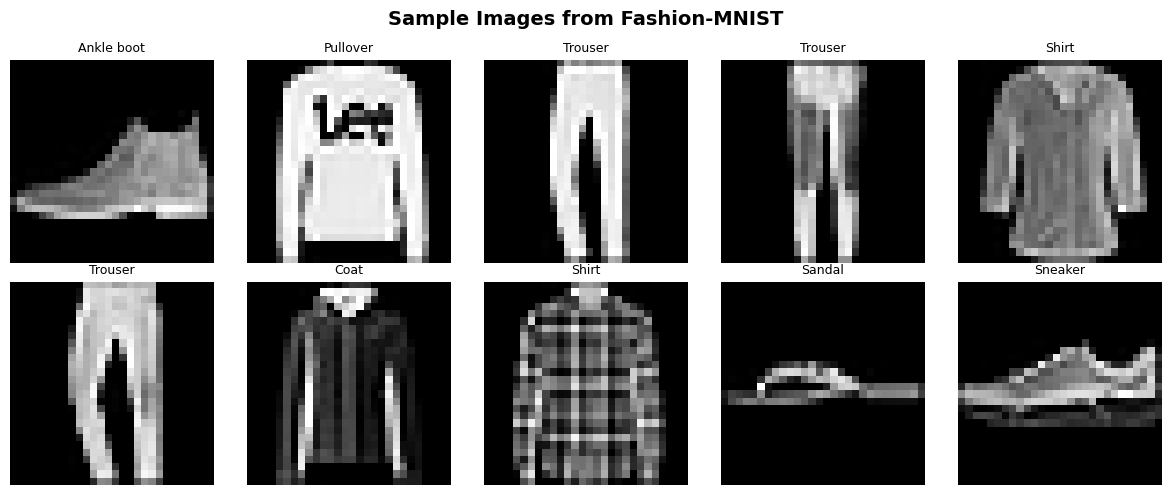

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from Fashion-MNIST', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img, label = testset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [32]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 28 -> 14
            nn.Dropout(0.20),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 14 -> 7
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 7 -> 3
            nn.Dropout(0.30)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inplace=Fals

In [33]:
epochs    = 50
patience  = 15

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print(f"Optimizer : Adam  (lr=5e-4, weight_decay=1e-4)")
print(f"Scheduler : CosineAnnealingLR  (T_max={epochs})")
print(f"Epochs    : {epochs}  |  Early stopping patience: {patience}")

Optimizer : Adam  (lr=5e-4, weight_decay=1e-4)
Scheduler : CosineAnnealingLR  (T_max=50)
Epochs    : 50  |  Early stopping patience: 15


In [34]:
counter   = 0
best_loss = float('inf')

train_losses,     val_losses     = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    # ── Training ──────────────────────────────────────────────────────
    model.train()
    running_loss = running_correct = total_train = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item()
        _, preds         = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_train     += labels.size(0)

    train_loss = running_loss / len(trainloader)
    train_acc  = running_correct / total_train

    # ── Validation ────────────────────────────────────────────────────
    model.eval()
    val_running_loss = val_running_correct = total_val = 0

    with torch.no_grad():
        for images, labels in validationloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_running_loss    += loss.item()
            _, preds             = torch.max(outputs, 1)
            val_running_correct += (preds == labels).sum().item()
            total_val           += labels.size(0)

    val_loss = val_running_loss / len(validationloader)
    val_acc  = val_running_correct / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1:2d}/{epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    # ── Early stopping ─────────────────────────────────────────────────
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best_model.pth'))
print("\nBest model loaded.")

Epoch [ 1/50]  Train Loss: 0.8839  Train Acc: 0.6706  Val Loss: 0.5284  Val Acc: 0.7944
Epoch [ 2/50]  Train Loss: 0.5930  Train Acc: 0.7795  Val Loss: 0.5067  Val Acc: 0.8143
Epoch [ 3/50]  Train Loss: 0.5221  Train Acc: 0.8070  Val Loss: 0.3951  Val Acc: 0.8501
Epoch [ 4/50]  Train Loss: 0.4790  Train Acc: 0.8222  Val Loss: 0.3607  Val Acc: 0.8673
Epoch [ 5/50]  Train Loss: 0.4533  Train Acc: 0.8323  Val Loss: 0.3423  Val Acc: 0.8727
Epoch [ 7/50]  Train Loss: 0.4158  Train Acc: 0.8469  Val Loss: 0.2883  Val Acc: 0.8956
Epoch [ 8/50]  Train Loss: 0.4022  Train Acc: 0.8517  Val Loss: 0.2835  Val Acc: 0.8959
Epoch [ 9/50]  Train Loss: 0.3927  Train Acc: 0.8548  Val Loss: 0.2889  Val Acc: 0.8920
Epoch [10/50]  Train Loss: 0.3791  Train Acc: 0.8594  Val Loss: 0.2733  Val Acc: 0.8976
Epoch [11/50]  Train Loss: 0.3698  Train Acc: 0.8642  Val Loss: 0.2606  Val Acc: 0.9049
Epoch [12/50]  Train Loss: 0.3672  Train Acc: 0.8647  Val Loss: 0.2512  Val Acc: 0.9064
Epoch [13/50]  Train Loss: 0.358

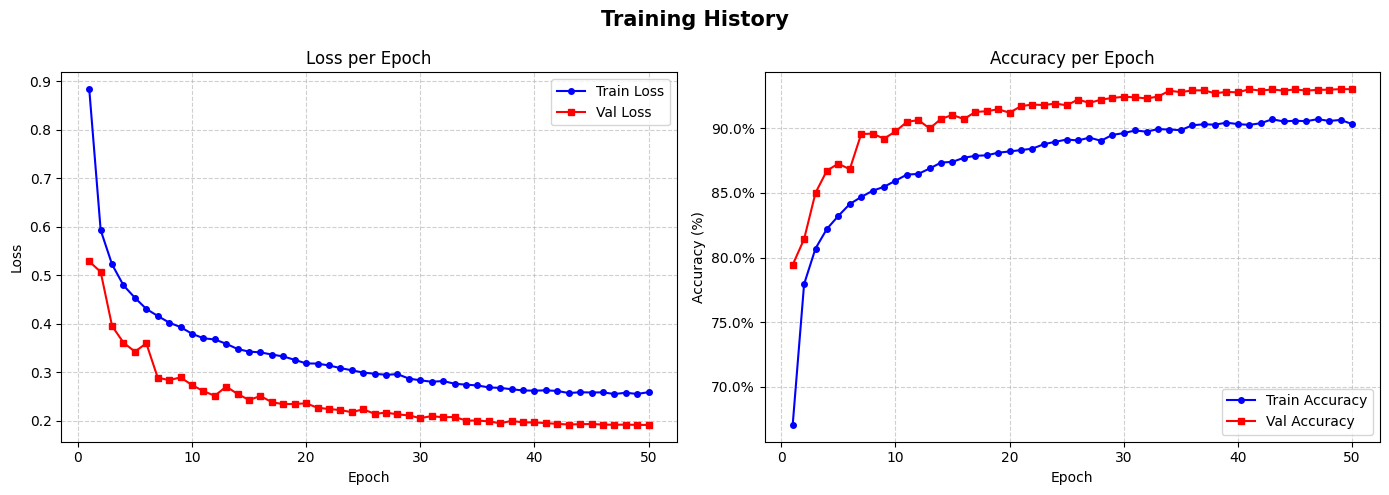

In [35]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
ax.plot(epochs_range, val_losses,   'r-s', markersize=4, label='Val Loss')
ax.set_title('Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Accuracy
ax = axes[1]
ax.plot(epochs_range, [a * 100 for a in train_accuracies], 'b-o', markersize=4, label='Train Accuracy')
ax.plot(epochs_range, [a * 100 for a in val_accuracies],   'r-s', markersize=4, label='Val Accuracy')
ax.set_title('Accuracy per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [36]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print("Test samples collected:", len(all_labels))

Test samples collected: 10000


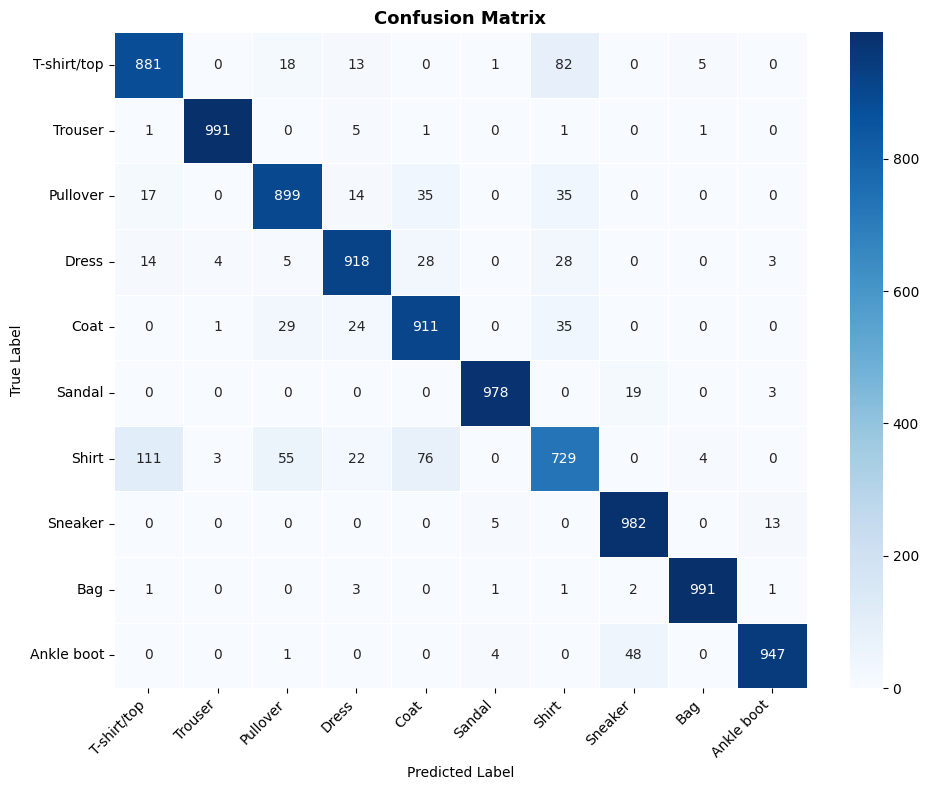

In [37]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
# Test loss
model.eval()
test_loss = 0.0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        test_loss += loss.item()
test_loss /= len(testloader)

# Metrics
overall_accuracy = accuracy_score(all_labels, all_preds)
macro_precision  = precision_score(all_labels, all_preds, average='macro')
macro_recall     = recall_score   (all_labels, all_preds, average='macro')
macro_f1         = f1_score       (all_labels, all_preds, average='macro')

# Print
print("Overall Performance Metrics:")
print("-" * 40)
print(f"Test Accuracy: {overall_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Precision:     {macro_precision:.4f}")
print(f"Recall:        {macro_recall:.4f}")
print(f"F1-Score:      {macro_f1:.4f}")

Overall Performance Metrics:
----------------------------------------
Test Accuracy: 0.9227
Test Loss:     0.2162
Precision:     0.9223
Recall:        0.9227
F1-Score:      0.9222
